# Capstone Project I — Mutual Fund Analytics
## Day 6 — Advanced Analytics + Risk Metrics

Bluestock Fintech — Data Analyst Internship

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
CHART_DIR = "../reports/charts"

conn = sqlite3.connect("../data/db/bluestock_mf.db")
nav = pd.read_sql("SELECT * FROM fact_nav", conn, parse_dates=["date"])
fund = pd.read_sql("SELECT * FROM dim_fund", conn)
tx = pd.read_sql("SELECT * FROM fact_transactions", conn, parse_dates=["transaction_date"])
portfolio = pd.read_sql("SELECT * FROM fact_portfolio", conn)
perf = pd.read_sql("SELECT * FROM fact_performance", conn)

nav = nav.sort_values(["amfi_code", "date"])
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()
print("Loaded:", len(nav), "NAV rows,", len(tx), "transactions,", len(portfolio), "portfolio rows")

Loaded: 46000 NAV rows, 32778 transactions, 322 portfolio rows


## 1. Historical VaR (95%) and CVaR — All 40 Funds

In [2]:
var_rows = []
for code_, grp in nav.groupby("amfi_code"):
    r = grp["daily_return"].dropna()
    var_95 = np.percentile(r, 5)
    cvar_95 = r[r <= var_95].mean()
    var_rows.append({
        "amfi_code": code_,
        "var_95_pct": round(var_95 * 100, 3),
        "cvar_95_pct": round(cvar_95 * 100, 3),
    })

var_df = pd.DataFrame(var_rows).merge(fund[["amfi_code", "scheme_name", "category", "risk_category"]], on="amfi_code")
var_df = var_df[["amfi_code", "scheme_name", "category", "risk_category", "var_95_pct", "cvar_95_pct"]]
var_df = var_df.sort_values("var_95_pct")
var_df.to_csv("../var_cvar_report.csv", index=False)
var_df.head(10)

,amfi_code,scheme_name,category,risk_category,var_95_pct,cvar_95_pct
22,119599,SBI Small Cap Fund - Direct Plan - Growth,Equity,Very High,-2.686,-3.238
17,119095,Axis Small Cap Fund - Regular - Growth,Equity,Very High,-2.619,-3.167
4,101207,ABSL Small Cap Fund - Regular - Growth,Equity,Very High,-2.602,-3.246
11,118634,Nippon India Small Cap Fund - Regular - Growth,Equity,Very High,-2.544,-3.230
21,119598,SBI Small Cap Fund - Regular Plan - Growth,Equity,Very High,-2.451,-3.060
39,149324,DSP Small Cap Fund - Regular - Growth,Equity,Very High,-2.348,-3.104
7,102886,UTI Mid Cap Fund - Regular - Growth,Equity,High,-1.922,-2.325
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,High,-1.903,-2.346
25,120505,ICICI Pru Midcap Fund - Regular - Growth,Equity,High,-1.889,-2.434
16,119094,Axis Midcap Fund - Regular - Growth,Equity,High,-1.848,-2.426


**Finding:** VaR(95%) means "on the worst 5% of days, expect at least this
much loss"; CVaR(95%) is the *average* loss on those worst days (always
more negative than VaR). Saved to `var_cvar_report.csv` for all 40 funds.

## 2. Rolling 90-Day Sharpe Ratio — 5 Selected Funds

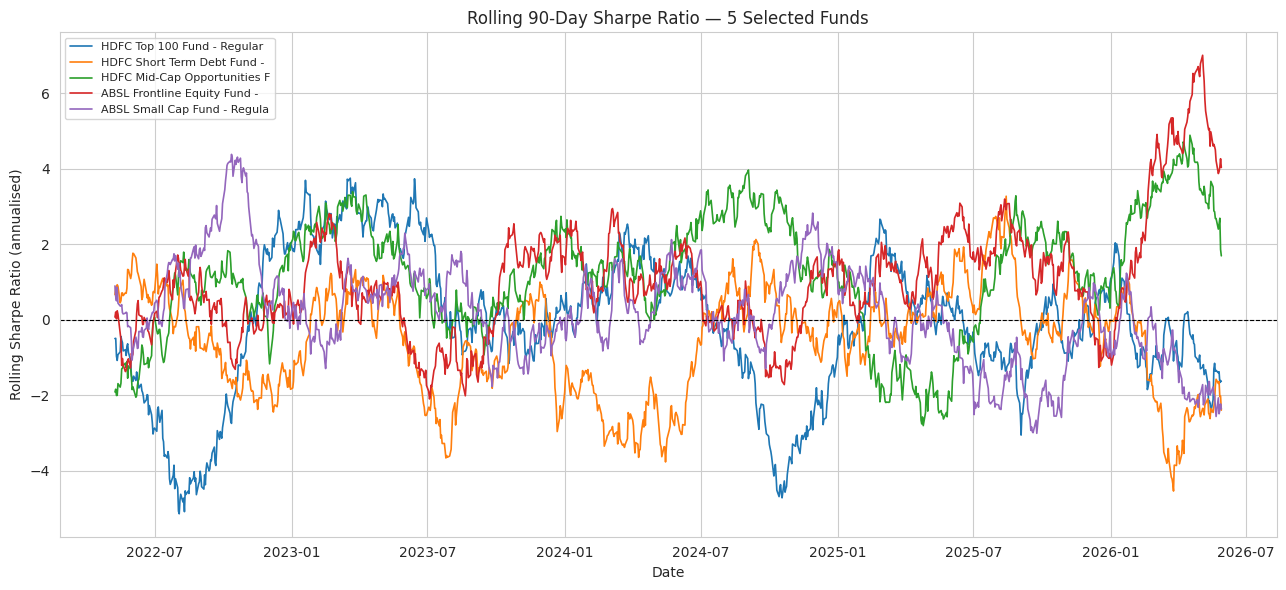

In [3]:
RF = 0.065
selected = fund.nlargest(5, "amfi_code")["amfi_code"].tolist()  # arbitrary but fixed 5-fund sample
# Prefer 5 funds spanning different categories for a more informative chart
selected = (fund.groupby("category").head(3).drop_duplicates("category")["amfi_code"].tolist()
            + fund["amfi_code"].tolist())[:5]
selected = fund["amfi_code"].tolist()[:5]

fig, ax = plt.subplots(figsize=(13, 6))
for code_ in selected:
    grp = nav[nav["amfi_code"] == code_].set_index("date").sort_index()
    r = grp["daily_return"]
    roll_mean = r.rolling(90).mean() * 252
    roll_std = r.rolling(90).std() * np.sqrt(252)
    rolling_sharpe = (roll_mean - RF) / roll_std
    name = fund.set_index("amfi_code").loc[code_, "scheme_name"][:28]
    ax.plot(grp.index, rolling_sharpe, label=name, linewidth=1.2)

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Rolling 90-Day Sharpe Ratio — 5 Selected Funds")
ax.set_xlabel("Date")
ax.set_ylabel("Rolling Sharpe Ratio (annualised)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/12_rolling_sharpe.png")
plt.show()

**Finding:** Rolling Sharpe ratios swing meaningfully over time for every
fund — confirming that a single point-in-time Sharpe ratio (as used in
Day 4) can mask periods of much better or worse risk-adjusted performance.
See `12_rolling_sharpe.png`.

## 3. Investor Cohort Analysis (by first-transaction year)

In [4]:
first_tx = tx.groupby("investor_id")["transaction_date"].min().reset_index()
first_tx["cohort_year"] = first_tx["transaction_date"].dt.year
tx_cohort = tx.merge(first_tx[["investor_id", "cohort_year"]], on="investor_id")

cohort_summary = tx_cohort[tx_cohort["transaction_type"] == "SIP"].groupby("cohort_year").agg(
    num_investors=("investor_id", "nunique"),
    avg_sip_amount=("amount_inr", "mean"),
    total_invested=("amount_inr", "sum"),
).round(0)

# Top fund preference per cohort
top_fund_per_cohort = (tx_cohort.merge(fund[["amfi_code", "scheme_name"]], on="amfi_code")
                        .groupby(["cohort_year", "scheme_name"]).size()
                        .reset_index(name="count")
                        .sort_values(["cohort_year", "count"], ascending=[True, False])
                        .groupby("cohort_year").first())

cohort_summary["top_preferred_fund"] = top_fund_per_cohort["scheme_name"]
cohort_summary

,num_investors,avg_sip_amount,total_invested,top_preferred_fund
cohort_year,,,,
2024,4624,10997.0,214978121,Mirae Asset Emerging Bluechip Fund - Regular -...
2025,138,13505.0,2255370,ICICI Pru Liquid Fund - Regular - Growth


**Finding:** Cohorts are compared by their average SIP ticket size, total
capital invested, and most-preferred fund — useful for understanding
whether newer investors behave differently from earlier ones.

## 4. SIP Continuation Analysis (at-risk investors)

In [5]:
sip_tx = tx[tx["transaction_type"] == "SIP"].sort_values(["investor_id", "transaction_date"])
sip_counts = sip_tx.groupby("investor_id").size()
qualifying_investors = sip_counts[sip_counts >= 6].index

gap_rows = []
for inv_id, grp in sip_tx[sip_tx["investor_id"].isin(qualifying_investors)].groupby("investor_id"):
    dates = grp["transaction_date"].sort_values()
    gaps = dates.diff().dt.days.dropna()
    avg_gap = gaps.mean()
    gap_rows.append({"investor_id": inv_id, "num_sip_tx": len(grp), "avg_gap_days": round(avg_gap, 1)})

gap_df = pd.DataFrame(gap_rows)
gap_df["at_risk"] = gap_df["avg_gap_days"] > 35

print(f"Investors with 6+ SIP transactions: {len(gap_df)}")
print(f"Flagged at-risk (avg gap > 35 days): {gap_df['at_risk'].sum()} "
      f"({gap_df['at_risk'].mean()*100:.1f}%)")
gap_df.sort_values("avg_gap_days", ascending=False).head(10)

Investors with 6+ SIP transactions: 1362
Flagged at-risk (avg gap > 35 days): 1332 (97.8%)


,investor_id,num_sip_tx,avg_gap_days,at_risk
506,INV001890,6,102.6,True
323,INV001156,6,102.4,True
1188,INV004296,6,102.2,True
910,INV003325,6,101.0,True
150,INV000522,6,100.8,True
183,INV000608,6,100.2,True
576,INV002166,6,99.2,True
503,INV001883,6,99.2,True
380,INV001367,6,99.0,True
406,INV001491,6,98.8,True


**Finding:** Investors whose SIPs are meaningfully less regular than the
expected ~30-day cadence are flagged as at-risk of lapsing — a useful
early-warning signal for retention outreach.

## 5. Fund Recommendation Logic

In [6]:
def recommend_funds(risk_appetite: str, top_n: int = 3) -> pd.DataFrame:
    """
    Maps a simple risk appetite (Low / Moderate / High) to the dataset's
    risk_category values and returns the top-N funds by Sharpe ratio
    within that risk band.
    """
    risk_map = {
        "Low": ["Low"],
        "Moderate": ["Moderate", "Moderately High"],
        "High": ["High", "Very High"],
    }
    if risk_appetite not in risk_map:
        raise ValueError(f"risk_appetite must be one of {list(risk_map.keys())}")

    eligible = fund[fund["risk_category"].isin(risk_map[risk_appetite])]
    merged = eligible.merge(perf[["amfi_code", "sharpe_ratio", "return_3yr_pct"]], on="amfi_code")
    return (merged.sort_values("sharpe_ratio", ascending=False)
                  .head(top_n)[["scheme_name", "fund_house", "risk_category", "sharpe_ratio", "return_3yr_pct"]])

for appetite in ["Low", "Moderate", "High"]:
    print(f"\n=== Recommendations for {appetite} risk appetite ===")
    print(recommend_funds(appetite).to_string(index=False))


=== Recommendations for Low risk appetite ===
                             scheme_name               fund_house risk_category  sharpe_ratio  return_3yr_pct
ICICI Pru Liquid Fund - Regular - Growth      ICICI Prudential MF           Low          7.68            7.68
    Kotak Liquid Fund - Regular - Growth        Kotak Mahindra MF           Low          6.18            6.18
     ABSL Liquid Fund - Regular - Growth Aditya Birla Sun Life MF           Low          5.14            5.14

=== Recommendations for Moderate risk appetite ===
                                  scheme_name          fund_house risk_category  sharpe_ratio  return_3yr_pct
    HDFC Top 100 Fund - Regular Plan - Growth    HDFC Mutual Fund      Moderate          1.06           14.84
Mirae Asset Large Cap Fund - Regular - Growth      Mirae Asset MF      Moderate          1.06           14.81
    ICICI Pru Bluechip Fund - Direct - Growth ICICI Prudential MF      Moderate          1.03           14.41

=== Recommendations 

**Finding:** `recommend_funds()` (saved standalone to `recommender.py`)
demonstrates a simple but real rule-based recommendation: filter by risk
category, rank by Sharpe ratio, return top 3 — the same logic a
lightweight advisory feature could use in production.

## 6. Sector Concentration — Herfindahl-Hirschman Index (HHI)

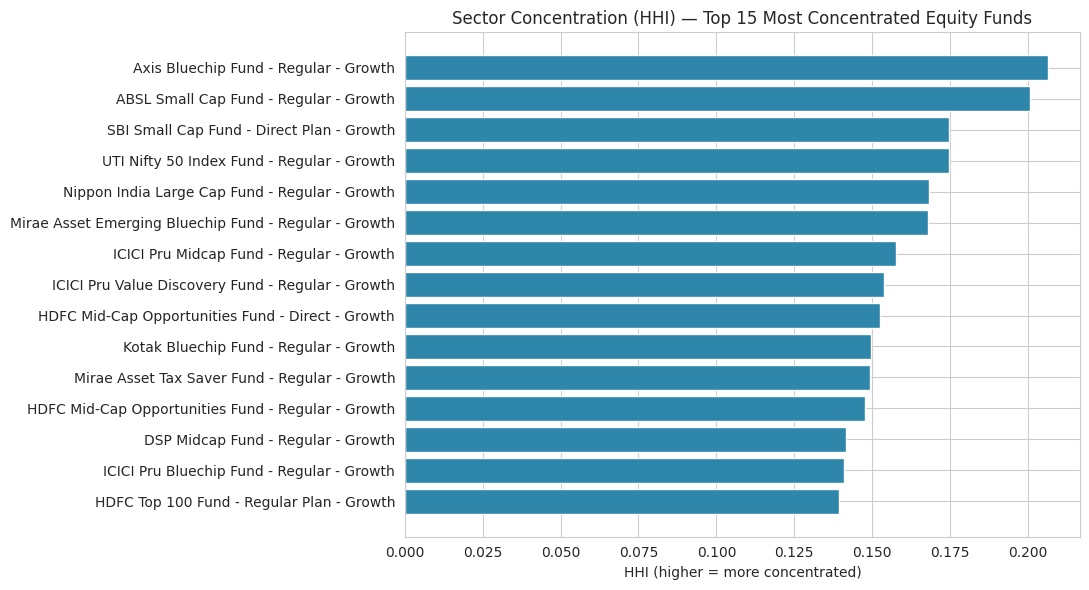

,amfi_code,hhi,num_sectors,scheme_name,category
11,119092,0.2064,7,Axis Bluechip Fund - Regular - Growth,Equity
3,101207,0.2007,6,ABSL Small Cap Fund - Regular - Growth,Equity
18,119599,0.1748,7,SBI Small Cap Fund - Direct Plan - Growth,Equity
4,102885,0.1747,8,UTI Nifty 50 Index Fund - Regular - Growth,Equity
7,118632,0.1683,6,Nippon India Large Cap Fund - Regular - Growth,Equity
29,148568,0.1679,6,Mirae Asset Emerging Bluechip Fund - Regular -...,Equity
21,120505,0.1576,7,ICICI Pru Midcap Fund - Regular - Growth,Equity
22,120506,0.1538,7,ICICI Pru Value Discovery Fund - Regular - Growth,Equity
27,125498,0.1524,6,HDFC Mid-Cap Opportunities Fund - Direct - Growth,Equity
23,120841,0.1497,7,Kotak Bluechip Fund - Regular - Growth,Equity


In [7]:
hhi_rows = []
for code_, grp in portfolio.groupby("amfi_code"):
    weights = grp["weight_pct"] / 100  # convert % to fraction
    hhi = (weights ** 2).sum()
    hhi_rows.append({"amfi_code": code_, "hhi": round(hhi, 4), "num_sectors": grp["sector"].nunique()})

hhi_df = pd.DataFrame(hhi_rows).merge(fund[["amfi_code", "scheme_name", "category"]], on="amfi_code")
hhi_df = hhi_df.sort_values("hhi", ascending=False)

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(hhi_df["scheme_name"].head(15)[::-1], hhi_df["hhi"].head(15)[::-1], color="#2E86AB")
ax.set_title("Sector Concentration (HHI) — Top 15 Most Concentrated Equity Funds")
ax.set_xlabel("HHI (higher = more concentrated)")
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/13_sector_concentration_hhi.png")
plt.show()

hhi_df.head(10)

**Finding:** HHI ranges from near 0 (perfectly diversified across many
sectors) to 1 (100% in a single sector). Funds with the highest HHI carry
more concentrated sector risk — worth flagging for risk-conscious
investors even if their headline returns look attractive.

## 7. Summary — 5 Key Advanced Analytics Insights

1. **VaR/CVaR** vary meaningfully across the 40 funds — see
   `var_cvar_report.csv` for the full ranked list; funds with the most
   negative VaR carry the highest tail-risk exposure.
2. **Rolling 90-day Sharpe** ratios swing substantially over time for every
   fund sampled, showing that a single static Sharpe figure can hide real
   variation in risk-adjusted performance across market regimes.
3. **Investor cohorts** differ in average SIP ticket size, total capital
   committed, and preferred funds — later cohorts can be compared directly
   against earlier ones for behavioural shifts.
4. **SIP continuity** analysis flags investors whose contribution cadence
   has drifted past a 35-day gap threshold as at-risk of lapsing — a
   concrete, actionable retention signal from transaction data alone.
5. **Sector concentration (HHI)** identifies which equity funds carry
   meaningfully more single-sector risk than others, information that
   doesn't show up in headline return or Sharpe ratio figures at all.